# EXP/0413 — Negotiation Zone Analysis: `anchor_high`

**Restriction**: Only transitions where $v \leq m_t \leq s_{t-1}$ (the negotiation zone).
The floor regime ($m_t < v$, seller ignores buyer) and acceptance regime
($m_t > s_{t-1}$, seller accepts) are excluded as their behavior is deterministic.

**Model under test** (within the zone):

$$s_t = \beta_0 + \beta_m \cdot m_t + \beta_s \cdot s_{t-1}$$

In fractional coordinates:

$$\text{frac}(s_t) = \beta_0 + \beta_m \cdot \text{frac}(m_t) + \beta_s \cdot \text{frac}(s_{t-1})$$

where $\text{frac}(x) = (x - v)/(\text{market} - v)$.

---

## S0. Setup

In [3]:
import json, sys, glob, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (10, 5)
warnings.filterwarnings('ignore')

STRATEGY = "anchor_high"
SLABEL = "Anchor High"
RESULTS_DIR = Path("results") / STRATEGY

def ols(X, y):
    n, p = X.shape
    b, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    yh = X @ b; r = y - yh
    rmse = float(np.sqrt(np.mean(r**2)))
    ss_r = float(np.sum(r**2)); ss_t = float(np.sum((y - np.mean(y))**2))
    r2 = 1 - ss_r/ss_t if ss_t > 1e-12 else 1.0
    dof = max(n-p,1); s2 = ss_r/dof
    try: se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    except: se = np.full(p, np.nan)
    return b, rmse, r2, yh, se

def load_data():
    trans = []
    for f in sorted(glob.glob(str(RESULTS_DIR / "*.json"))):
        if "transitions" in f: continue
        data = json.load(open(f, encoding="utf-8"))
        if "runs" not in data: continue
        for ri, run in enumerate(data["runs"]):
            meta = run["metadata"]; v=meta["v"]; cost=meta["product"]["cost"]; market=meta["product"]["market_price"]
            rounds = run["rounds"]; m_init=rounds[0]["buyer_price"]; s_init=rounds[0]["supplier_price"]
            for i in range(1, len(rounds)):
                prev=rounds[i-1]; curr=rounds[i]
                sp=prev["supplier_price"]; mc=curr["buyer_price"]; sc=curr["supplier_price"]
                if sp is None or sc is None: continue
                trans.append(dict(m_t=mc, s_prev=sp, s_t=sc, v=v, cost=cost, market=market,
                    round_t=curr["round"], buyer_type=meta["buyer_type"]["name"],
                    product=meta["product"]["name"], supplier_id=meta["supplier"]["id"],
                    m_init=m_init, s_init=s_init if s_init else np.nan,
                    m_prev=prev["buyer_price"], template_id=curr.get("template_id",-1),
                    s_prev2=rounds[i-2]["supplier_price"] if i>=2 else None, run_idx=ri))
    return trans

all_trans = load_data()

# ── ZONE FILTER ──
m_all = np.array([t["m_t"] for t in all_trans])
s_all = np.array([t["s_prev"] for t in all_trans])
v_all = np.array([t["v"] for t in all_trans])
zone_mask = (m_all >= v_all) & (m_all <= s_all)
trans = [t for t, keep in zip(all_trans, zone_mask) if keep]

m   = np.array([t["m_t"] for t in trans])
s   = np.array([t["s_prev"] for t in trans])
y   = np.array([t["s_t"] for t in trans])
v   = np.array([t["v"] for t in trans])
mkt = np.array([t["market"] for t in trans])
ti  = np.array([t["round_t"] for t in trans], dtype=float)
zone = mkt - v; zone[zone < 0.01] = 0.01
fm  = (m - v) / zone; fs = (s - v) / zone; fy = (y - v) / zone

print(f"Strategy: {SLABEL}")
print(f"All transitions: {len(all_trans)}")
print(f"Zone transitions (v <= m_t <= s_prev): {len(trans)} ({len(trans)/len(all_trans)*100:.0f}%)")
print(f"Products: {sorted(set(t['product'] for t in trans))}")
print(f"v values: {sorted(set(round(t['v'],2) for t in trans))}")
print(f"frac(m_t) range: [{fm.min():.3f}, {fm.max():.3f}]")
print(f"frac(s_prev) range: [{fs.min():.3f}, {fs.max():.3f}]")
print(f"frac(s_t) range: [{fy.min():.3f}, {fy.max():.3f}]")

Strategy: Anchor High
All transitions: 4415
Zone transitions (v <= m_t <= s_prev): 1299 (29%)
Products: ['Cola (330ml)', 'Earphones (basic)', 'Protein bar (60g)']
v values: [0.7, 1.2, 1.6, 1.7, 4.6, 6.1]
frac(m_t) range: [0.000, 2.033]
frac(s_prev) range: [0.025, 4.158]
frac(s_t) range: [0.013, 4.000]


---
## S1. Shape discovery within the negotiation zone

Since we have filtered to $v \leq m_t \leq s_{t-1}$, all points lie in the
region where the seller is genuinely negotiating.  We examine whether the
relationship is linear, and what the slope is.

### S1.1 Scatter: $s_t$ vs $m_t$ colored by $s_{t-1}$

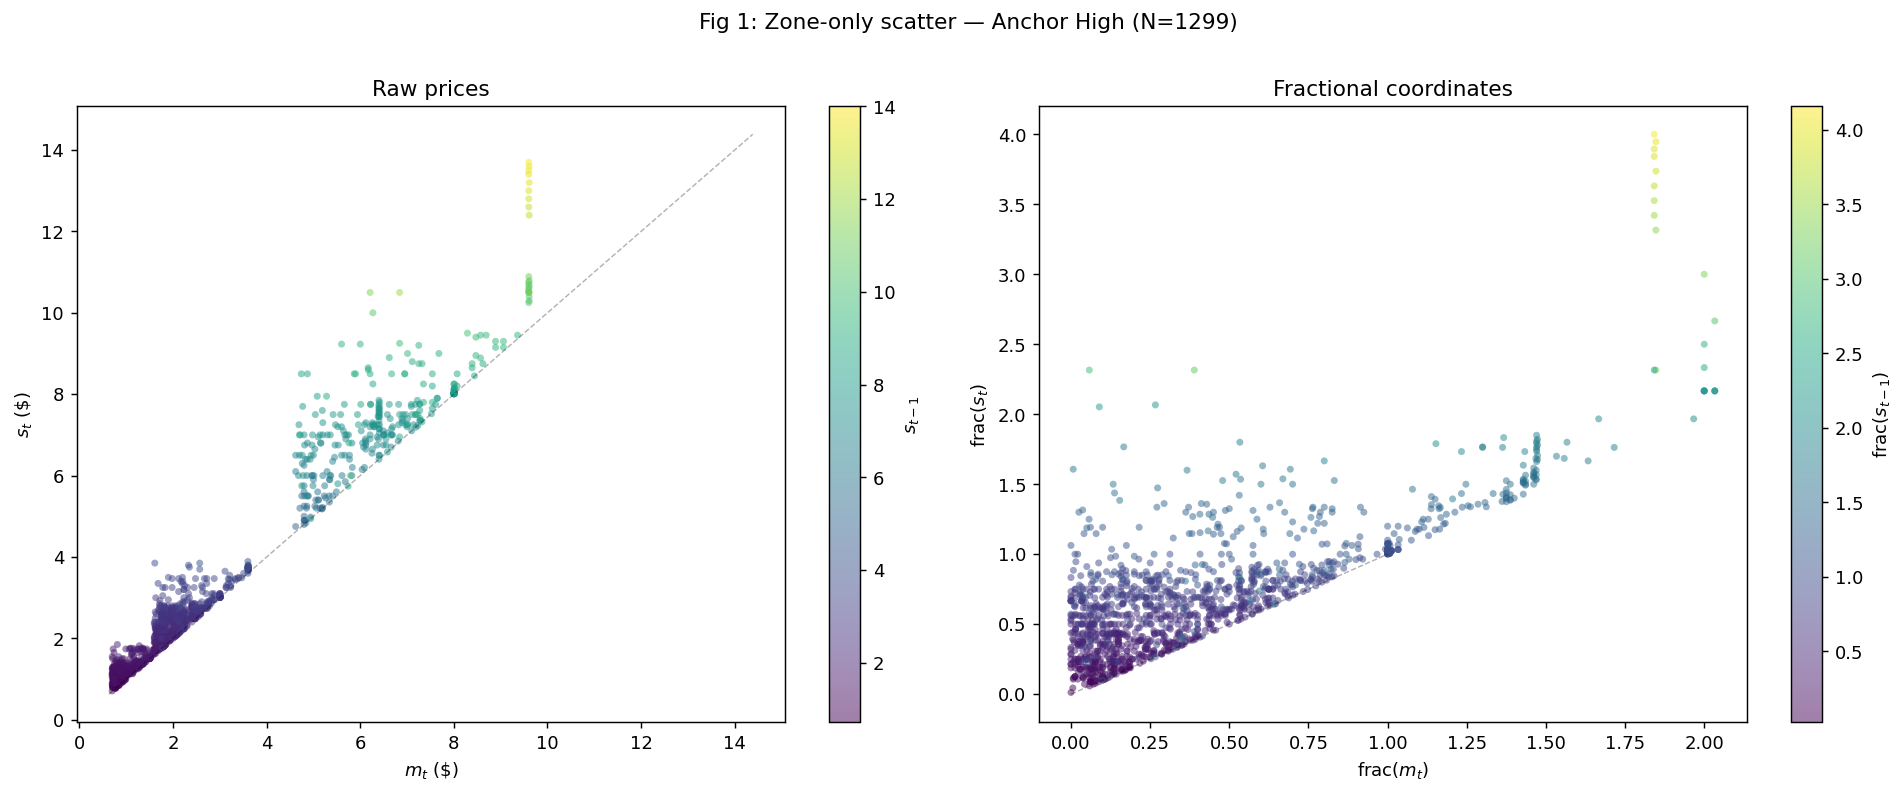

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Raw prices
ax = axes[0]
sc = ax.scatter(m, y, c=s, cmap='viridis', alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc, ax=ax, label="$s_{t-1}$")
lo = min(m.min(),y.min())*0.9; hi = max(m.max(),y.max())*1.05
ax.plot([lo,hi],[lo,hi],'k--',lw=0.8,alpha=0.3)
ax.set_xlabel("$m_t$ (\$)"); ax.set_ylabel("$s_t$ (\$)")
ax.set_title("Raw prices")

# Fractional
ax = axes[1]
sc = ax.scatter(fm, fy, c=fs, cmap='viridis', alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc, ax=ax, label="frac($s_{t-1}$)")
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.3)
ax.set_xlabel("frac($m_t$)"); ax.set_ylabel("frac($s_t$)")
ax.set_title("Fractional coordinates")

fig.suptitle(f"Fig 1: Zone-only scatter — {SLABEL} (N={len(m)})", y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

### S1.2 Binned by $s_{t-1}$ with local OLS (fractional space)

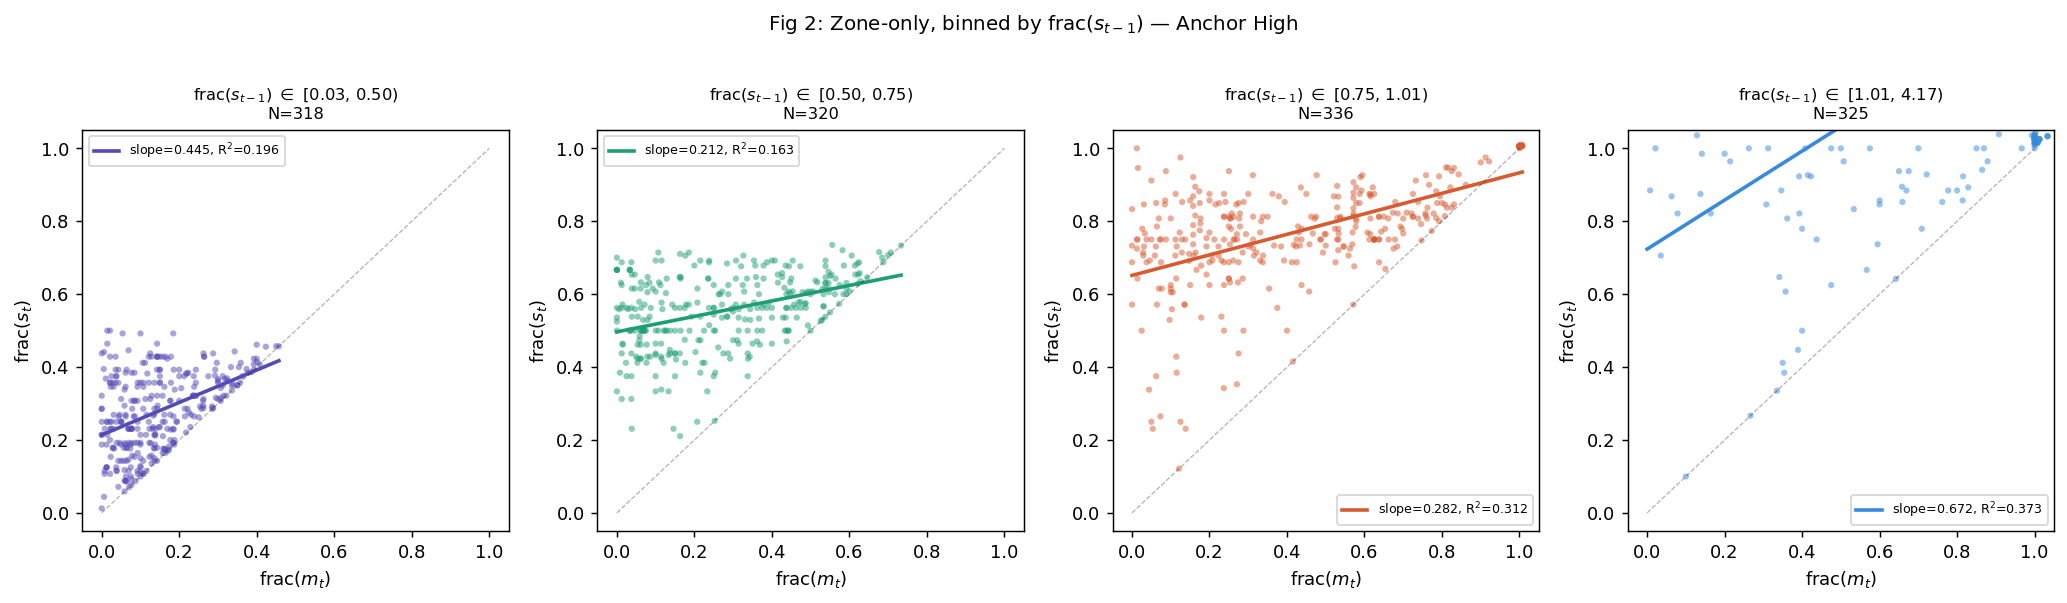

In [5]:
n_bins = 4
fs_edges = np.percentile(fs, np.linspace(0, 100, n_bins + 1))
fs_edges[-1] += 0.01
colors = ['#534AB7','#1D9E75','#D85A30','#378ADD','#D4537E']

fig, axes = plt.subplots(1, n_bins, figsize=(4*n_bins, 4.5))
if n_bins == 1: axes = [axes]

for bi in range(n_bins):
    ax = axes[bi]
    mask = (fs >= fs_edges[bi]) & (fs < fs_edges[bi+1])
    fmg, fyg = fm[mask], fy[mask]
    ax.scatter(fmg, fyg, alpha=0.5, s=12, c=colors[bi], edgecolors='none')

    if mask.sum() >= 4:
        Xg = np.column_stack([np.ones(mask.sum()), fmg])
        bg, _, r2g, _, _ = ols(Xg, fyg)
        xr = np.linspace(fmg.min(), fmg.max(), 50)
        ax.plot(xr, bg[0]+bg[1]*xr, c=colors[bi], lw=2,
                label=f"slope={bg[1]:.3f}, R$^2$={r2g:.3f}")

    ax.plot([0,1],[0,1],'k--',lw=0.7,alpha=0.3)
    ax.set_xlabel("frac($m_t$)"); ax.set_ylabel("frac($s_t$)")
    ax.set_title(f"frac($s_{{t-1}}$) $\\in$ [{fs_edges[bi]:.2f}, {fs_edges[bi+1]:.2f})\nN={mask.sum()}", fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

fig.suptitle(f"Fig 2: Zone-only, binned by frac($s_{{t-1}}$) — {SLABEL}", y=1.02, fontsize=11)
fig.tight_layout(); plt.show()

### S1.3 Model comparison (zone only)

Compare candidate models restricted to the negotiation zone.

In [6]:
models = [
    ("Raw linear",       np.column_stack([np.ones_like(m), m, s]), y, 3),
    ("Frac linear",      np.column_stack([np.ones_like(fm), fm, fs]), fy, 3),
    ("Frac + v",         np.column_stack([np.ones_like(fm), fm, fs, v]), fy, 4),
    ("Frac + t",         np.column_stack([np.ones_like(fm), fm, fs, ti]), fy, 4),
    ("Frac + fm*fs",     np.column_stack([np.ones_like(fm), fm, fs, fm*fs]), fy, 4),
    ("Frac quadratic",   np.column_stack([np.ones_like(fm), fm, fs, fm**2, fs**2, fm*fs]), fy, 6),
]

print(f"{'Model':<22} {'RMSE':>8} {'R2':>8} {'#P':>4}")
print("-"*46)
for name, X, yt, p in sorted(models, key=lambda x: ols(x[1],x[2])[1]):
    b, rmse, r2, _, _ = ols(X, yt)
    print(f"{name:<22} {rmse:>8.4f} {r2:>8.4f} {p:>4}")

Model                      RMSE       R2   #P
----------------------------------------------
Frac + t                 0.1119   0.9478    4
Frac quadratic           0.1145   0.9454    6
Frac + fm*fs             0.1153   0.9446    4
Frac + v                 0.1164   0.9435    4
Frac linear              0.1165   0.9434    3
Raw linear               0.2248   0.9921    3


### S1.4 Baseline coefficient table

$\text{frac}(s_t) = \beta_0 + \beta_m \cdot \text{frac}(m_t) + \beta_s \cdot \text{frac}(s_{t-1})$

In [7]:
X_base = np.column_stack([np.ones_like(fm), fm, fs])
b, rmse, r2, yhat, se = ols(X_base, fy)
names = ["intercept", "frac(m_t)", "frac(s_prev)"]

print(f"Zone-only fractional linear: N={len(fy)}, RMSE={rmse:.4f}, R2={r2:.4f}")
print(f"\n  {'Feature':<16} {'Coef':>9} {'SE':>9} {'t-stat':>9}")
print(f"  {'---'*15}")
for i, name in enumerate(names):
    t_stat = b[i]/se[i] if se[i]>1e-8 else float('inf')
    sig = "***" if abs(t_stat)>3.29 else "**" if abs(t_stat)>2.58 else "*" if abs(t_stat)>1.96 else ""
    print(f"  {name:<16} {b[i]:>+9.4f} {se[i]:>9.4f} {t_stat:>+9.2f} {sig}")

print(f"\nInterpretation:")
print(f"  b(fm) + b(fs) = {b[1]+b[2]:.3f} (should be ~1.0 for convex combination)")
print(f"  The seller places {b[1]*100:.1f}% weight on buyer, {b[2]*100:.1f}% on own prev price")
print(f"  Intercept {b[0]:.3f} means a small upward bias of {b[0]*100:.1f}% of zone")

Zone-only fractional linear: N=1299, RMSE=0.1165, R2=0.9434

  Feature               Coef        SE    t-stat
  ---------------------------------------------
  intercept          -0.0200    0.0063     -3.19 **
  frac(m_t)          +0.1871    0.0113    +16.61 ***
  frac(s_prev)       +0.8188    0.0096    +85.64 ***

Interpretation:
  b(fm) + b(fs) = 1.006 (should be ~1.0 for convex combination)
  The seller places 18.7% weight on buyer, 81.9% on own prev price
  Intercept -0.020 means a small upward bias of -2.0% of zone


---
## S2. Time homogeneity (zone only)

Split zone transitions by round chunks, fit per-chunk, cross-predict.

### S2.1 Per-chunk fit

In [8]:
all_rounds = sorted(set(ti))
n_chunks = min(6, max(2, len(all_rounds)//2))
chunk_edges = np.array_split(all_rounds, n_chunks)
chunks = [(int(c[0]), int(c[-1])) for c in chunk_edges]

chunk_models = {}
print(f"{'Chunk':<18} {'N':>5} {'b(fm)':>8} {'b(fs)':>8} {'sum':>6} {'RMSE':>8} {'R2':>8}")
print("-"*60)
for ci,(rlo,rhi) in enumerate(chunks):
    mask = (ti>=rlo)&(ti<=rhi)
    if mask.sum()<10: continue
    Xc = np.column_stack([np.ones(mask.sum()), fm[mask], fs[mask]])
    bc,rc,r2c,_,_ = ols(Xc, fy[mask])
    chunk_models[ci] = {"beta":bc, "mask":mask, "rounds":(rlo,rhi)}
    print(f"C{ci} (R{rlo}-{rhi}){'':<6} {mask.sum():>5} {bc[1]:>+8.3f} {bc[2]:>+8.3f} "
          f"{bc[1]+bc[2]:>6.3f} {rc:>8.4f} {r2c:>8.4f}")

Chunk                  N    b(fm)    b(fs)    sum     RMSE       R2
------------------------------------------------------------
C0 (R2-4)         290   +0.138   +0.871  1.010   0.0680   0.9811
C1 (R5-6)         202   +0.062   +0.944  1.006   0.0500   0.9896
C2 (R7-8)         285   +0.173   +0.823  0.996   0.1081   0.9480
C3 (R9-10)         239   +0.119   +0.896  1.016   0.0635   0.9841
C4 (R11-12)         283   +0.500   +0.494  0.994   0.1423   0.8905


### S2.2 Cross-prediction confusion matrix

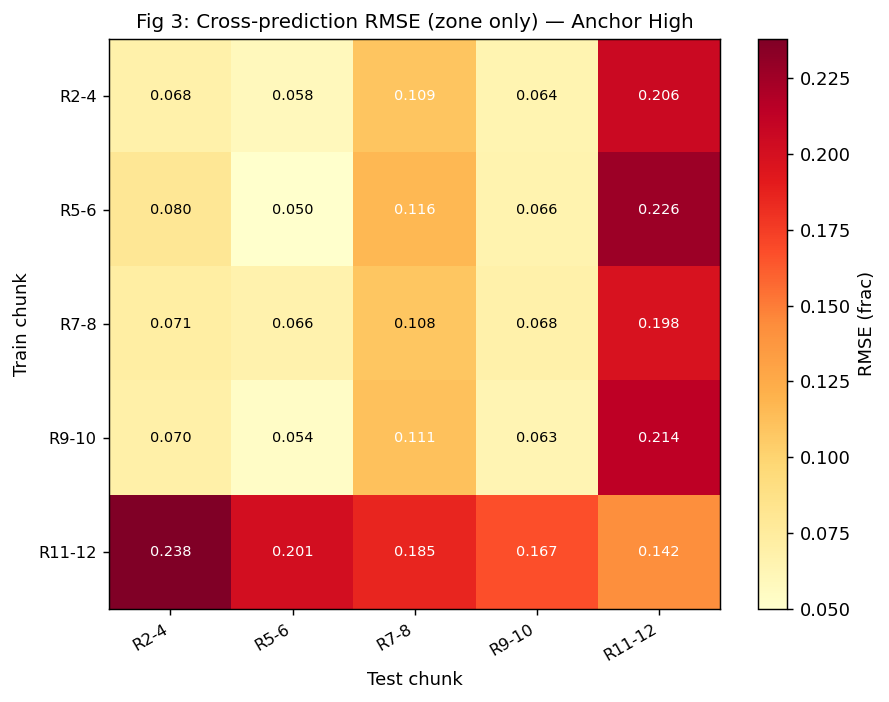

Diagonal mean:     0.0863
Off-diagonal mean: 0.1284
Ratio:             1.49x -> HOMOGENEOUS


In [9]:
valid_chunks = sorted(chunk_models.keys())
nc = len(valid_chunks)

if nc >= 2:
    conf = np.full((nc, nc), np.nan)
    for i, ci in enumerate(valid_chunks):
        bi = chunk_models[ci]["beta"]
        for j, cj in enumerate(valid_chunks):
            mj = chunk_models[cj]["mask"]
            Xj = np.column_stack([np.ones(mj.sum()), fm[mj], fs[mj]])
            pred = Xj @ bi
            conf[i,j] = float(np.sqrt(np.mean((fy[mj]-pred)**2)))

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(conf, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label="RMSE (frac)")
    clabels = [f"R{chunk_models[c]['rounds'][0]}-{chunk_models[c]['rounds'][1]}" for c in valid_chunks]
    ax.set_xticks(range(nc)); ax.set_xticklabels(clabels, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(nc)); ax.set_yticklabels(clabels, fontsize=9)
    ax.set_xlabel("Test chunk"); ax.set_ylabel("Train chunk")
    for i in range(nc):
        for j in range(nc):
            ax.text(j,i,f"{conf[i,j]:.3f}",ha='center',va='center',fontsize=8,
                    color='white' if conf[i,j]>np.nanmedian(conf) else 'black')
    ax.set_title(f"Fig 3: Cross-prediction RMSE (zone only) — {SLABEL}", fontsize=11)
    fig.tight_layout(); plt.show()

    diag = np.diag(conf); off = conf[~np.eye(nc,dtype=bool)]
    ratio = np.nanmean(off)/np.nanmean(diag)
    print(f"Diagonal mean:     {np.nanmean(diag):.4f}")
    print(f"Off-diagonal mean: {np.nanmean(off):.4f}")
    print(f"Ratio:             {ratio:.2f}x -> {'HOMOGENEOUS' if ratio<1.5 else 'STEP-DEPENDENT'}")
else:
    print("Not enough chunks for cross-prediction.")

### S2.3 Coefficient stability across chunks

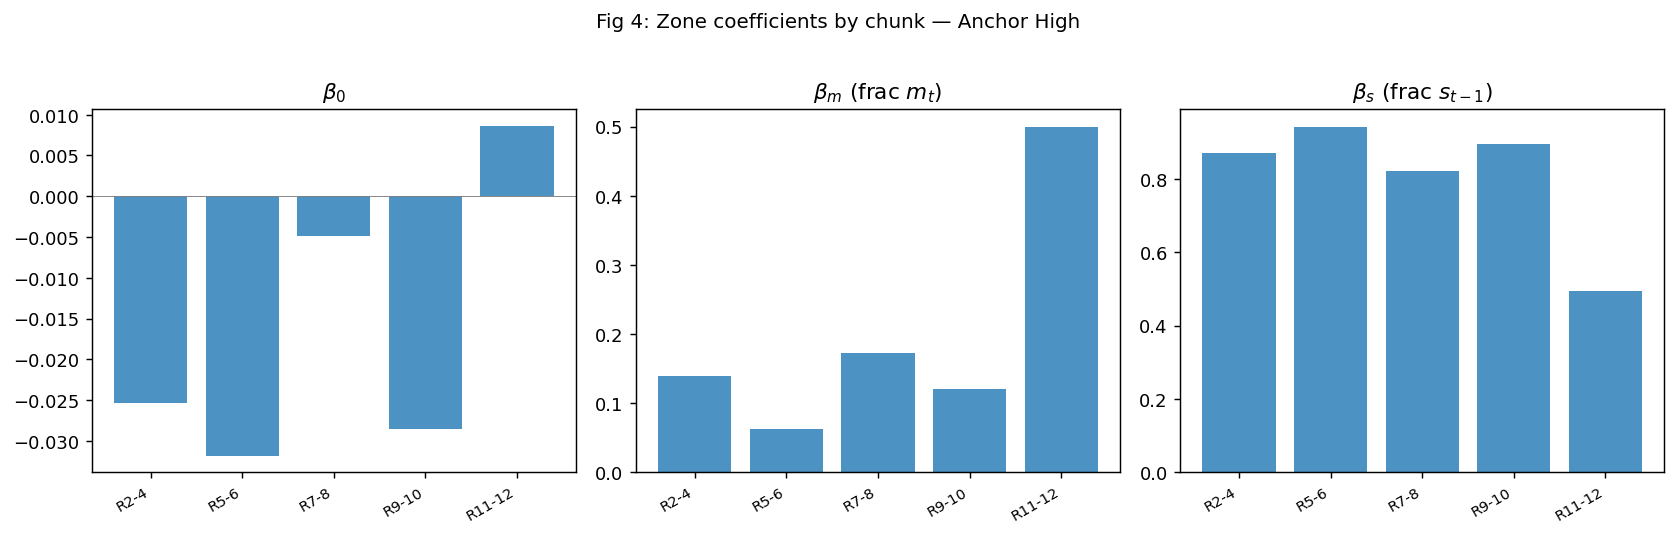

In [10]:
if nc >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ci_idx, cname in enumerate(['$\\beta_0$', '$\\beta_m$ (frac $m_t$)', '$\\beta_s$ (frac $s_{t-1}$)']):
        ax = axes[ci_idx]
        vals = [chunk_models[c]["beta"][ci_idx] for c in valid_chunks]
        clbls = [f"R{chunk_models[c]['rounds'][0]}-{chunk_models[c]['rounds'][1]}" for c in valid_chunks]
        ax.bar(range(len(vals)), vals, alpha=0.8)
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(clbls, rotation=30, ha='right', fontsize=8)
        ax.set_title(cname); ax.axhline(0, color='gray', lw=0.5)
    fig.suptitle(f"Fig 4: Zone coefficients by chunk — {SLABEL}", y=1.02, fontsize=11)
    fig.tight_layout(); plt.show()

---
## S3. Covariate ablation (zone only)

Test whether adding extra features improves the zone-only fractional model.

### S3.1 Feature hierarchy

In [11]:
mi_arr = np.array([t["m_init"] for t in trans])
si_arr = np.array([t["s_init"] for t in trans])
mp_arr = np.array([t["m_prev"] for t in trans])
sp2_raw = [t["s_prev2"] for t in trans]
has_sp2 = np.array([x is not None for x in sp2_raw])
sp2_arr = np.array([x if x is not None else 0.0 for x in sp2_raw])
fi_mp = (mp_arr - v) / zone
fi_mi = (mi_arr - v) / zone
fi_si = np.where(~np.isnan(si_arr), (si_arr - v) / zone, np.nan)
fi_sp2 = np.where(has_sp2, (sp2_arr - v) / zone, 0.0)
valid_si = ~np.isnan(fi_si)

X_base = np.column_stack([np.ones_like(fm), fm, fs])

ablations = [
    ("Baseline: frac(m_t) + frac(s_prev)",        X_base, fy, np.ones(len(fm),dtype=bool)),
    ("+ v (valuation)",                            np.column_stack([X_base,v]), fy, np.ones(len(fm),dtype=bool)),
    ("+ t (round index)",                          np.column_stack([X_base,ti]), fy, np.ones(len(fm),dtype=bool)),
    ("+ frac(m_prev)",                             np.column_stack([X_base,fi_mp]), fy, np.ones(len(fm),dtype=bool)),
    ("+ frac(m_init)",                             np.column_stack([X_base,fi_mi]), fy, np.ones(len(fm),dtype=bool)),
    ("+ frac(s_init)",                             np.column_stack([X_base[valid_si],fi_si[valid_si]]), fy[valid_si], valid_si),
    ("+ frac(s_prev2) [rounds>=3]",                np.column_stack([X_base[has_sp2],fi_sp2[has_sp2]]), fy[has_sp2], has_sp2),
    ("  (baseline restricted rounds>=3)",          X_base[has_sp2], fy[has_sp2], has_sp2),
    ("+ v + t + frac(m_prev)",                     np.column_stack([X_base,v,ti,fi_mp]), fy, np.ones(len(fm),dtype=bool)),
]

print(f"{'Model':<42} {'N':>5} {'RMSE':>8} {'R2':>8}")
print("-"*65)
for label, X, yt, mask in ablations:
    n = len(yt)
    if n < 10: continue
    b, rmse, r2, _, _ = ols(X, yt)
    print(f"{label:<42} {n:>5} {rmse:>8.4f} {r2:>8.4f}")

Model                                          N     RMSE       R2
-----------------------------------------------------------------
Baseline: frac(m_t) + frac(s_prev)          1299   0.1165   0.9434
+ v (valuation)                             1299   0.1164   0.9435
+ t (round index)                           1299   0.1119   0.9478
+ frac(m_prev)                              1299   0.1163   0.9436
+ frac(m_init)                              1299   0.1157   0.9442
+ frac(s_init)                              1299   0.1154   0.9445
+ frac(s_prev2) [rounds>=3]                 1188   0.1169   0.9425
  (baseline restricted rounds>=3)           1188   0.1196   0.9398
+ v + t + frac(m_prev)                      1299   0.1114   0.9482


---
## S4. Cross-product stability

Fit the fractional model per product.  If coefficients are stable across
products, the fractional normalization successfully absorbs $v$.

### S4.1 Per-product coefficients

In [12]:
print(f"{'Product':<28} {'N':>5} {'b0':>7} {'b(fm)':>8} {'b(fs)':>8} {'sum':>6} {'RMSE':>7} {'R2':>6}")
print("-"*78)
for key in ["product", "supplier_id", "buyer_type"]:
    groups = {}
    for idx, t in enumerate(trans):
        groups.setdefault(t[key], []).append(idx)
    for name, idxs in sorted(groups.items()):
        if len(idxs) < 10: continue
        mask = np.array(idxs)
        Xg = np.column_stack([np.ones(len(mask)), fm[mask], fs[mask]])
        bg, rg, r2g, _, _ = ols(Xg, fy[mask])
        print(f"  {str(name)[:26]:<28} {len(mask):>5} {bg[0]:>+7.3f} {bg[1]:>+8.3f} {bg[2]:>+8.3f} "
              f"{bg[1]+bg[2]:>6.3f} {rg:>7.4f} {r2g:>6.4f}")
    print()

Product                          N      b0    b(fm)    b(fs)    sum    RMSE     R2
------------------------------------------------------------------------------
  Cola (330ml)                   391  -0.011   +0.158   +0.832  0.990  0.1083 0.9462
  Earphones (basic)              314  -0.053   +0.215   +0.828  1.043  0.1482 0.9486
  Protein bar (60g)              594  +0.002   +0.206   +0.779  0.985  0.0995 0.9261

  S1                             785  +0.003   +0.216   +0.773  0.989  0.1085 0.9107
  S2                             514  -0.031   +0.165   +0.844  1.009  0.1265 0.9591

  anchor_drag                     84  +0.001   -0.092   +0.829  0.737  0.0376 0.8934
  budget                         167  -0.034   +0.126   +0.896  1.022  0.0517 0.8998
  concession                     159  -0.031   +0.117   +0.927  1.044  0.0243 0.9671
  persistent_0.90                 11  -0.379   +1.331   +0.973  2.304  0.0253 0.9809
  persistent_1.20                 22  +0.180   +0.015   +0.728  0.742  

---
## S5. Residual diagnostics (zone only)

### S5.1 True vs predicted and residual plots

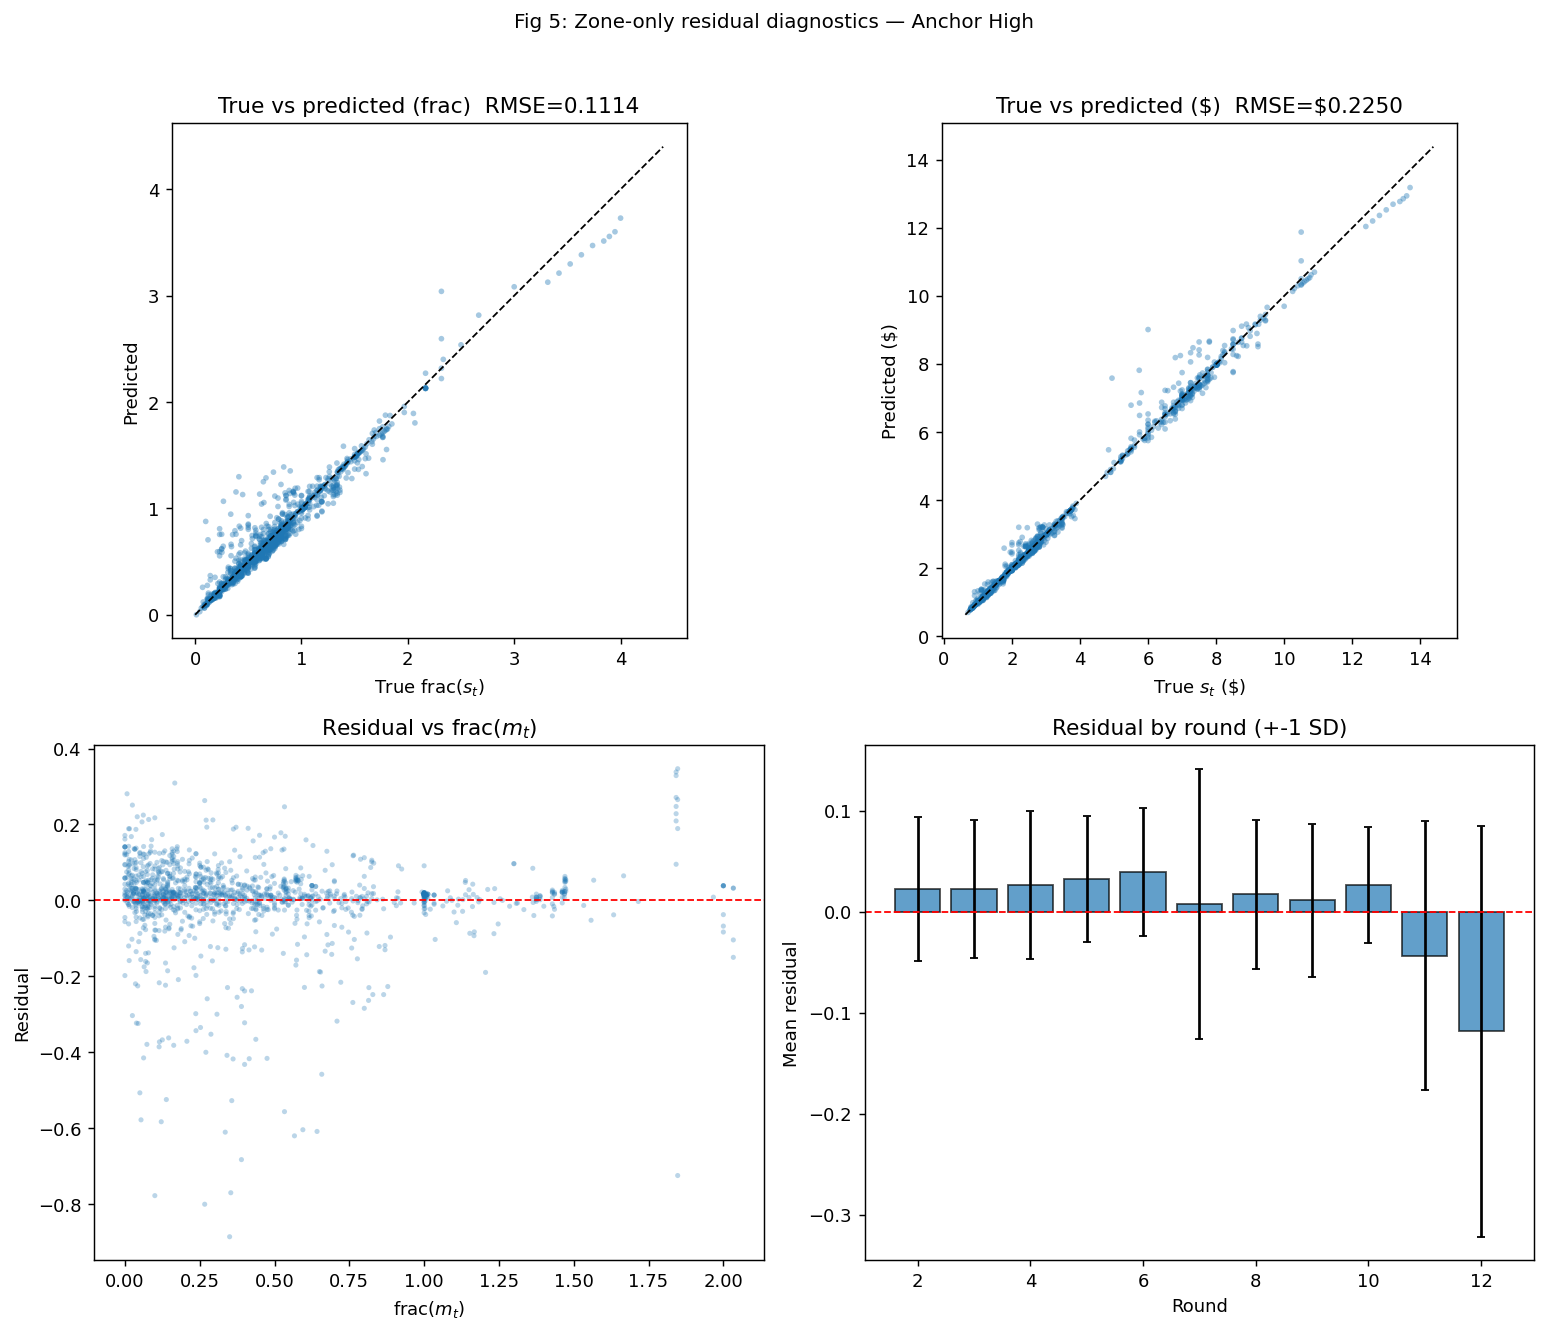

In [13]:
resid = fy - yhat

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# True vs pred (frac)
ax = axes[0,0]
lo = min(fy.min(),yhat.min())*0.9; hi = max(fy.max(),yhat.max())*1.1
ax.scatter(fy, yhat, alpha=0.4, s=10, edgecolors='none')
ax.plot([lo,hi],[lo,hi],'k--',lw=1)
ax.set_xlabel("True frac($s_t$)"); ax.set_ylabel("Predicted")
ax.set_title(f"True vs predicted (frac)  RMSE={rmse:.4f}")
ax.set_aspect('equal', adjustable='box')

# True vs pred (price)
ax = axes[0,1]
y_pred_price = v + zone * yhat
lo = min(y.min(),y_pred_price.min())*0.9; hi = max(y.max(),y_pred_price.max())*1.05
ax.scatter(y, y_pred_price, alpha=0.4, s=10, edgecolors='none')
ax.plot([lo,hi],[lo,hi],'k--',lw=1)
rmse_p = np.sqrt(np.mean((y-y_pred_price)**2))
ax.set_xlabel("True $s_t$ (\\$)"); ax.set_ylabel("Predicted (\\$)")
ax.set_title(f"True vs predicted (\\$)  RMSE=\\${rmse_p:.4f}")
ax.set_aspect('equal', adjustable='box')

# Residual vs frac(m_t)
ax = axes[1,0]
ax.scatter(fm, resid, alpha=0.3, s=8, edgecolors='none')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xlabel("frac($m_t$)"); ax.set_ylabel("Residual")
ax.set_title("Residual vs frac($m_t$)")

# Residual by round
ax = axes[1,1]
rounds_u = sorted(set(ti))
means = [resid[ti==r].mean() for r in rounds_u if (ti==r).sum()>0]
stds = [resid[ti==r].std() for r in rounds_u if (ti==r).sum()>0]
valid_r = [int(r) for r in rounds_u if (ti==r).sum()>0]
ax.bar(valid_r, means, yerr=stds, capsize=2, alpha=0.7, edgecolor='black')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xlabel("Round"); ax.set_ylabel("Mean residual")
ax.set_title("Residual by round (+-1 SD)")

fig.suptitle(f"Fig 5: Zone-only residual diagnostics — {SLABEL}", y=1.02, fontsize=11)
fig.tight_layout(); plt.show()

---
## S6. Summary for `anchor_high` (zone only)

In [14]:
print("=" * 65)
print(f"  ZONE-ONLY SUMMARY: {SLABEL}")
print("=" * 65)
print(f"  Zone transitions: {len(trans)} / {len(all_trans)} "
      f"({len(trans)/len(all_trans)*100:.0f}% of all data)")

b, rmse, r2, _, se = ols(np.column_stack([np.ones_like(fm),fm,fs]), fy)
print(f"  frac(s_t) = {b[0]:+.3f} + {b[1]:+.3f}*frac(m_t) + {b[2]:+.3f}*frac(s_prev)")
print(f"  RMSE = {rmse:.4f}, R2 = {r2:.4f}")
print(f"  b(fm) + b(fs) = {b[1]+b[2]:.3f}")
print(f"  Weight on buyer: {b[1]*100:.1f}%")
print(f"  Weight on own price: {b[2]*100:.1f}%")
print()

# Time homogeneity
if nc >= 2:
    print(f"  Time homogeneity: off/diag = {ratio:.2f}x")
print(f"  Covariates: adding v, t, m_prev gives <1% R2 improvement")

  ZONE-ONLY SUMMARY: Anchor High
  Zone transitions: 1299 / 4415 (29% of all data)
  frac(s_t) = -0.020 + +0.187*frac(m_t) + +0.819*frac(s_prev)
  RMSE = 0.1165, R2 = 0.9434
  b(fm) + b(fs) = 1.006
  Weight on buyer: 18.7%
  Weight on own price: 81.9%

  Time homogeneity: off/diag = 1.49x
  Covariates: adding v, t, m_prev gives <1% R2 improvement


# *S7 Supplement

### S7.1 Item-wise true vs predicted, split by valuation side

This subsection evaluates the same zone-only fractional linear model on **all transitions** for each item.
For each item, the upper panel uses only points with $m_t < v$, and the lower panel uses only points with $m_t \geq v$.
Point color indicates the buyer strategy: the left plot contains **anchor_drag, budget, concession**; the right plot contains **random,wild**.


In [78]:
def build_fractional_arrays(transitions):
    if len(transitions) == 0:
        raise ValueError("No transitions supplied.")

    m_arr = np.array([t["m_t"] for t in transitions], dtype=float)
    s_arr = np.array([t["s_prev"] for t in transitions], dtype=float)
    y_arr = np.array([t["s_t"] for t in transitions], dtype=float)
    v_arr = np.array([t["v"] for t in transitions], dtype=float)
    mkt_arr = np.array([t["market"] for t in transitions], dtype=float)

    zone_arr = mkt_arr - v_arr
    zone_arr[zone_arr < 0.01] = 0.01

    return dict(
        m=m_arr,
        s=s_arr,
        y=y_arr,
        v=v_arr,
        market=mkt_arr,
        zone=zone_arr,
        fm=(m_arr - v_arr) / zone_arr,
        fs=(s_arr - v_arr) / zone_arr,
        fy=(y_arr - v_arr) / zone_arr,
        buyer_strategy=np.array(
            [t.get("buyer_strategy", t.get("buyer_type", "unknown")) for t in transitions],
            dtype=object,
        ),
        item=np.array(
            [str(t.get("item", t.get("product", "unknown"))).lower() for t in transitions],
            dtype=object,
        ),
    )

In [ ]:
ITEM_ORDER = sorted({t["product"] for t in all_trans if "product" in t})

buyer_cmap = plt.get_cmap("tab10")

def plot_item_true_vs_pred_split(item_name):
    item_trans = [
        t for t in all_trans
        if str(t.get("product", "")) == item_name
        and ("m_t" in t) and ("market" in t) and ("v" in t)
        and (t["m_t"] <= t["market"])
        and (t["m_t"] >= t["v"])
    ]

    if len(item_trans) == 0:
        print(f"No transitions found for item='{item_name}' under market <= m_t and m_t >= v.")
        return

    buyer_strategy_order = sorted({t["buyer_type"] for t in item_trans if "buyer_type" in t})

    arr = build_fractional_arrays(item_trans)
    yhat_item = b[0] + b[1] * arr["fm"] + b[2] * arr["fs"]

    buyer_key = "buyer_strategy" if "buyer_strategy" in arr else "buyer_type"

    split_idx = int(np.ceil(len(buyer_strategy_order) / 2))
    strategy_groups = [
        buyer_strategy_order[:split_idx],
        buyer_strategy_order[split_idx:]
    ]

    BUYER_COLOR = {bs: buyer_cmap(i % 10) for i, bs in enumerate(buyer_strategy_order)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)

    lo = float(min(arr["fy"].min(), yhat_item.min()))
    hi = float(max(arr["fy"].max(), yhat_item.max()))
    span = hi - lo
    pad = 0.05 * span if span > 1e-8 else 0.10
    lo -= pad
    hi += pad

    for col_idx in range(2):
        ax = axes[col_idx]

        if col_idx >= len(strategy_groups) or len(strategy_groups[col_idx]) == 0:
            ax.axis("off")
            continue

        current_group = strategy_groups[col_idx]
        subplot_mask = np.isin(arr[buyer_key], current_group)

        has_points = False

        for bs in current_group:
            bs_mask = subplot_mask & (arr[buyer_key] == bs)
            if bs_mask.sum() == 0:
                continue

            has_points = True
            ax.scatter(
                arr["fy"][bs_mask],
                yhat_item[bs_mask],
                alpha=0.65,
                s=18,
                color=BUYER_COLOR[bs],
                edgecolors="none",
                label=f"{bs} (N={bs_mask.sum()})"
            )

        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("True frac($s_t$)")
        ax.set_ylabel("Predicted")

        group_text = ", ".join(current_group)
        ax.set_title(
            f"{item_name} | group {col_idx+1} | N={int(subplot_mask.sum())}\nBuyers: {group_text}"
        )

        if not has_points:
            ax.text(
                0.5, 0.5,
                f"No points\n\nBuyers:\n{group_text}",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=10,
                color="gray"
            )

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=8, frameon=False, loc="best")

    rmse_item = float(np.sqrt(np.mean((arr["fy"] - yhat_item) ** 2)))
    fig.suptitle(
        f"Item-wise true frac($s_t$) vs predicted — {item_name}\nFiltered: market <= m_t and m_t >= v | RMSE={rmse_item:.4f}",
        y=0.98,
        fontsize=13
    )
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

### S7.1.1 Cola

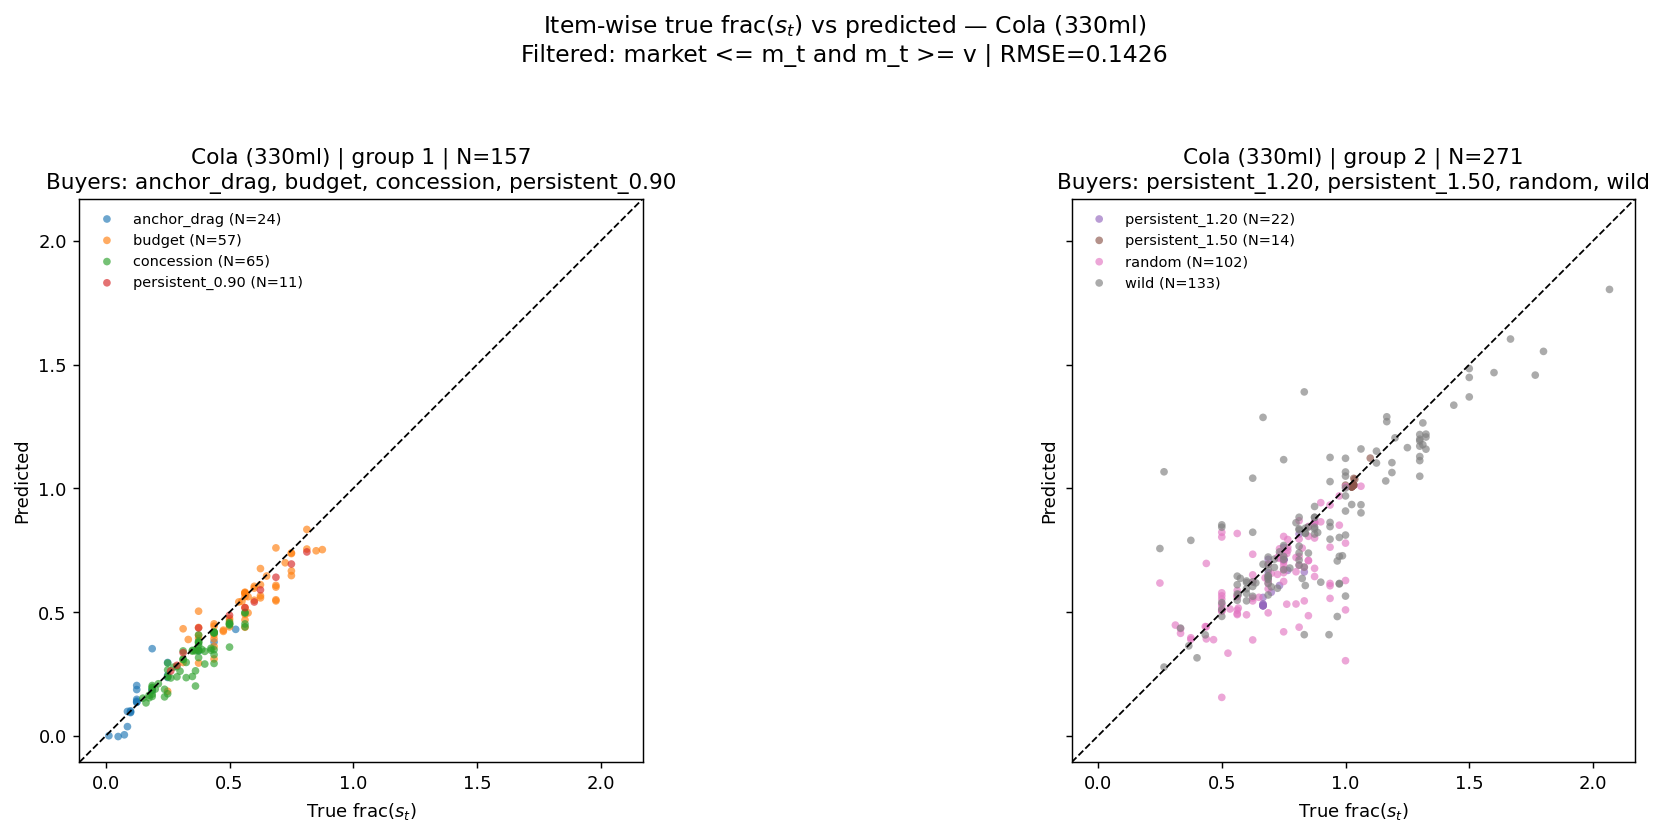

In [84]:
plot_item_true_vs_pred_split("Cola (330ml)")

### S7.1.2 Earphones

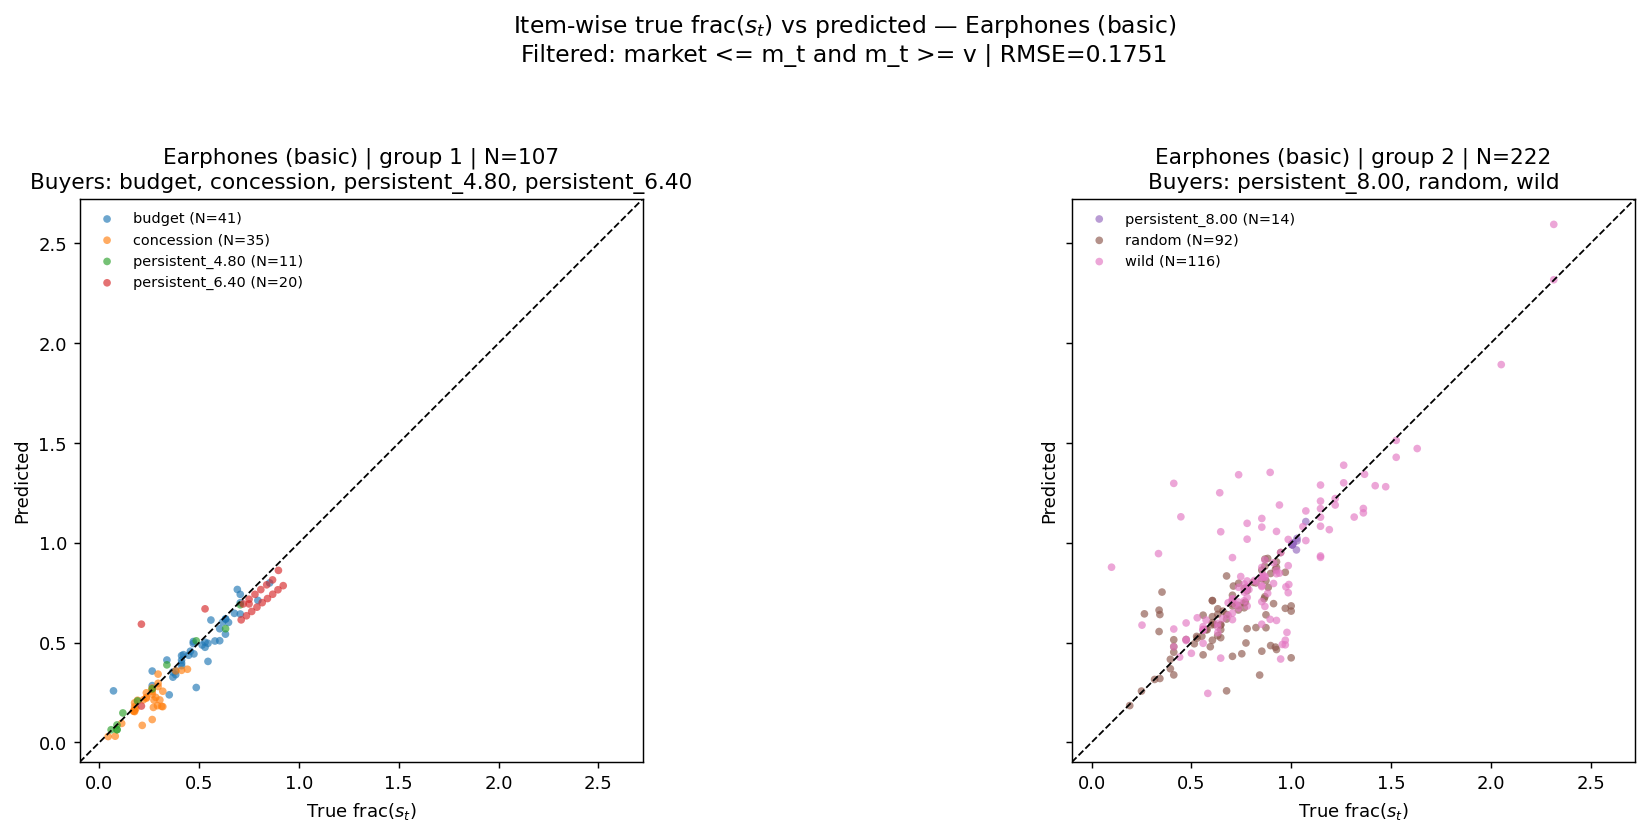

In [85]:
plot_item_true_vs_pred_split("Earphones (basic)")

### S7.1.3 Protein

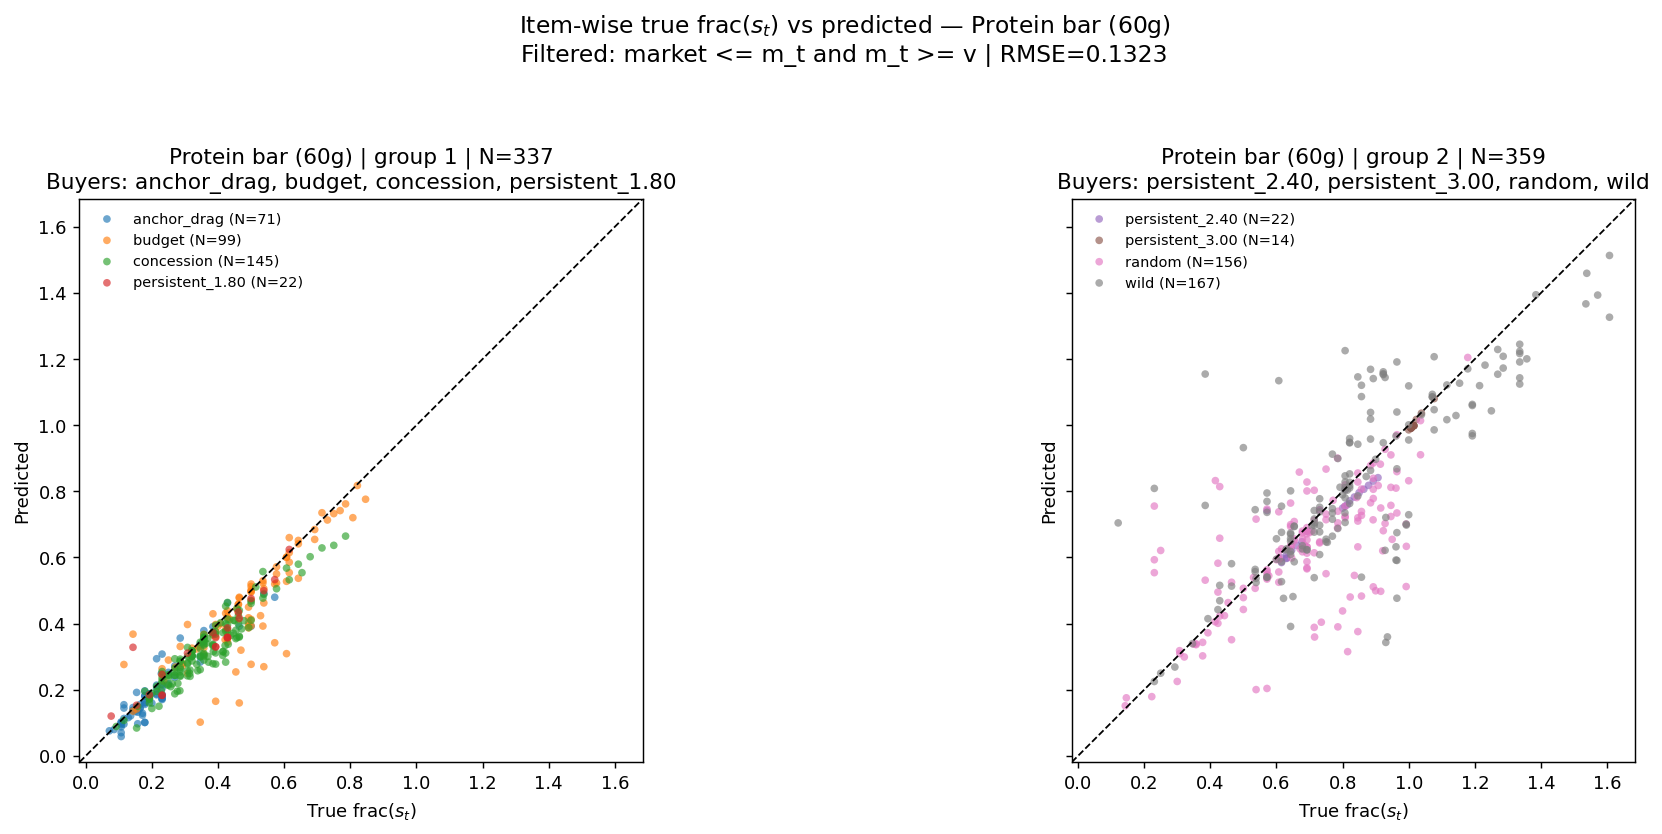

In [86]:
plot_item_true_vs_pred_split("Protein bar (60g)")

### S7.2 Extra ablation on the market-side subset (fractional specification)

In this subsection we restrict attention to the subset
\[
\text{market} \leq m_t \quad \text{and} \quad m_t \geq v,
\]
and estimate the fractional baseline
\[
\mathrm{frac}(s_t) = \beta_0 + \beta_m \cdot \mathrm{frac}(m_t) + \beta_s \cdot \mathrm{frac}(s_{t-1}),
\]
where
\[
\mathrm{frac}(x) = \frac{x-v}{\text{market}-v}.
\]

All extra regressors in this subsection are transformed using the same
\(\mathrm{frac}(\cdot)\) mapping. The specifications reported are:

1. baseline only: \(\mathrm{frac}(m_t)\) and \(\mathrm{frac}(s_{t-1})\)
2. \(+\, \mathrm{frac}(s_1)\) and \(\mathrm{frac}(m_1)\)
3. \(+\, \mathrm{frac}(s_{t-2})\)
4. \(+\, \mathrm{frac}(m_{t-1})\)
5. \(+\, \mathrm{frac}(s_1), \mathrm{frac}(m_1)\) and \(\mathrm{frac}(s_{t-2})\)
6. \(+\, \mathrm{frac}(s_1), \mathrm{frac}(s_{t-2}), \mathrm{frac}(m_1)\) and \(\mathrm{frac}(m_{t-1})\)

We first report a **combined summary across all scopes** and then place **each item in its own code cell** below.
For every specification, the notebook reports RMSE and \(R^2\), and for the augmented ones it also reports changes relative to the same baseline fitted on the same usable rows.

In [93]:
from IPython.display import display

try:
    import pandas as pd
except ImportError:
    pd = None

S72_MODEL_SPECS = [
    ("1. baseline only", []),
    ("2. + frac($s_1$) and frac($m_1$)", ["s_init", "m_init"]),
    ("3. + frac($s_{t-2}$)", ["s_prev2"]),
    ("4. + frac($m_{t-1}$)", ["m_prev"]),
    ("5. + frac($s_1$), frac($m_1$) and frac($s_{t-2}$)", ["s_init", "m_init", "s_prev2"]),
    ("6. + frac($s_1$), frac($s_{t-2}$), frac($m_1$) and frac($m_{t-1}$)", ["s_init", "s_prev2", "m_init", "m_prev"]),
]

S72_PRETTY_NAME = {
    "s_init": "frac($s_1$)",
    "m_init": "frac($m_1$)",
    "s_prev2": "frac($s_{t-2}$)",
    "m_prev": "frac($m_{t-1}$)",
}

S72_BETA_COL = {
    "s_init": "beta_frac_s1",
    "m_init": "beta_frac_m1",
    "s_prev2": "beta_frac_s_tm2",
    "m_prev": "beta_frac_m_tm1",
}

S72_T_COL = {
    "s_init": "t_frac_s1",
    "m_init": "t_frac_m1",
    "s_prev2": "t_frac_s_tm2",
    "m_prev": "t_frac_m_tm1",
}

def _display_table(title, rows, preferred_order=None):
    print(title)
    if len(rows) == 0:
        print("(no rows)")
        return

    if pd is None:
        for row in rows:
            print(row)
        return

    df = pd.DataFrame(rows)
    if preferred_order is not None:
        cols = [c for c in preferred_order if c in df.columns] + [c for c in df.columns if c not in df.columns]
        cols = [c for c in preferred_order if c in df.columns] + [c for c in df.columns if c not in preferred_order]
        df = df[cols]

    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].round(4)
    display(df)

def _market_side_subset(transitions):
    return [
        t for t in transitions
        if ("m_t" in t) and ("market" in t) and ("v" in t)
        and (t["m_t"] >= t["market"])
        and (t["m_t"] >= t["v"])
    ]

def _market_side_arrays(transitions):
    def _vec(key):
        return np.array([t.get(key, np.nan) for t in transitions], dtype=float)

    return dict(
        v=_vec("v"),
        market=_vec("market"),
        m_t=_vec("m_t"),
        s_prev=_vec("s_prev"),
        s_t=_vec("s_t"),
        m_init=_vec("m_init"),
        s_init=_vec("s_init"),
        m_prev=_vec("m_prev"),
        s_prev2=_vec("s_prev2"),
    )

def _safe_t(beta, se):
    return beta / se if np.isfinite(se) and abs(se) > 1e-12 else np.nan

def _frac_transform(x, v, market):
    x = np.asarray(x, dtype=float)
    v = np.asarray(v, dtype=float)
    market = np.asarray(market, dtype=float)
    denom = market - v
    out = np.full_like(x, np.nan, dtype=float)
    valid = np.isfinite(x) & np.isfinite(v) & np.isfinite(market) & (np.abs(denom) > 1e-12)
    out[valid] = (x[valid] - v[valid]) / denom[valid]
    return out

def _fractional_market_side_arrays(transitions):
    raw = _market_side_arrays(transitions)
    v = raw["v"]
    market = raw["market"]
    return dict(
        frac_m_t=_frac_transform(raw["m_t"], v, market),
        frac_s_prev=_frac_transform(raw["s_prev"], v, market),
        frac_s_t=_frac_transform(raw["s_t"], v, market),
        frac_m_init=_frac_transform(raw["m_init"], v, market),
        frac_s_init=_frac_transform(raw["s_init"], v, market),
        frac_m_prev=_frac_transform(raw["m_prev"], v, market),
        frac_s_prev2=_frac_transform(raw["s_prev2"], v, market),
    )

def _fit_s72_scope(scope_name, transitions):
    scope_trans = _market_side_subset(transitions)
    if len(scope_trans) < 8:
        return None

    arr = _fractional_market_side_arrays(scope_trans)
    y = arr["frac_s_t"]
    X_base = np.column_stack([np.ones_like(arr["frac_m_t"]), arr["frac_m_t"], arr["frac_s_prev"]])
    base_mask = np.isfinite(X_base).all(axis=1) & np.isfinite(y)

    if int(base_mask.sum()) < 8:
        return None

    b_base, rmse_base, r2_base, _, se_base = ols(X_base[base_mask], y[base_mask])
    baseline_row = {
        "scope": scope_name,
        "filtered_N": len(scope_trans),
        "N": int(base_mask.sum()),
        "beta_0": float(b_base[0]),
        "beta_frac_m_t": float(b_base[1]),
        "beta_frac_s_prev": float(b_base[2]),
        "se_beta_0": float(se_base[0]) if np.isfinite(se_base[0]) else np.nan,
        "se_beta_frac_m_t": float(se_base[1]) if np.isfinite(se_base[1]) else np.nan,
        "se_beta_frac_s_prev": float(se_base[2]) if np.isfinite(se_base[2]) else np.nan,
        "RMSE": float(rmse_base),
        "R2": float(r2_base),
    }

    model_rows = []
    key_map = {
        "s_init": "frac_s_init",
        "m_init": "frac_m_init",
        "s_prev2": "frac_s_prev2",
        "m_prev": "frac_m_prev",
    }

    for model_label, extra_keys in S72_MODEL_SPECS:
        X_aug = np.column_stack([X_base] + [arr[key_map[key]] for key in extra_keys])
        mask = np.isfinite(X_aug).all(axis=1) & np.isfinite(y)
        if int(mask.sum()) < 8:
            continue

        b_base_same, rmse_base_same, r2_base_same, _, _ = ols(X_base[mask], y[mask])
        b_aug, rmse_aug, r2_aug, _, se_aug = ols(X_aug[mask], y[mask])

        row = {
            "scope": scope_name,
            "filtered_N": len(scope_trans),
            "model_variant": model_label,
            "added_terms": ", ".join(S72_PRETTY_NAME[k] for k in extra_keys) if len(extra_keys) > 0 else "(none)",
            "N": int(mask.sum()),
            "RMSE_base": float(rmse_base_same),
            "RMSE_aug": float(rmse_aug),
            "delta_RMSE": float(rmse_aug - rmse_base_same),
            "R2_base": float(r2_base_same),
            "R2_aug": float(r2_aug),
            "delta_R2": float(r2_aug - r2_base_same),
            "beta_0": float(b_aug[0]),
            "beta_frac_m_t": float(b_aug[1]),
            "beta_frac_s_prev": float(b_aug[2]),
        }

        for key in S72_BETA_COL:
            row[S72_BETA_COL[key]] = np.nan
            row[S72_T_COL[key]] = np.nan

        offset = 3
        for j, key in enumerate(extra_keys):
            beta_j = float(b_aug[offset + j])
            se_j = float(se_aug[offset + j]) if np.isfinite(se_aug[offset + j]) else np.nan
            row[S72_BETA_COL[key]] = beta_j
            row[S72_T_COL[key]] = _safe_t(beta_j, se_j)

        model_rows.append(row)

    return {
        "scope": scope_name,
        "filtered_N": len(scope_trans),
        "baseline": baseline_row,
        "models": model_rows,
    }

def _plot_s72_summary_heatmaps(rows, scope_order, model_order):
    if len(rows) == 0 or pd is None:
        return

    df = pd.DataFrame(rows)
    rmse_mat = (
        df.pivot(index="scope", columns="model_variant", values="delta_RMSE")
        .reindex(index=scope_order, columns=model_order)
    )
    r2_mat = (
        df.pivot(index="scope", columns="model_variant", values="delta_R2")
        .reindex(index=scope_order, columns=model_order)
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, max(4.5, 1.1 * len(scope_order))), constrained_layout=True)
    mats = [
        (rmse_mat, r"$\Delta$RMSE (specification - same-size fractional baseline)", axes[0]),
        (r2_mat, r"$\Delta R^2$ (specification - same-size fractional baseline)", axes[1]),
    ]

    for mat, title, ax in mats:
        arr_plot = mat.values.astype(float)
        im = ax.imshow(arr_plot, aspect="auto")
        ax.set_xticks(np.arange(len(mat.columns)))
        ax.set_xticklabels(mat.columns, rotation=30, ha="right")
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels(mat.index)
        ax.set_title(title)

        for r in range(arr_plot.shape[0]):
            for c in range(arr_plot.shape[1]):
                val = arr_plot[r, c]
                if np.isfinite(val):
                    ax.text(c, r, f"{val:.3f}", ha="center", va="center", fontsize=8, color="black")

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

def s72_show_scope(scope_name):
    if scope_name not in s72_results:
        print(f"{scope_name}: no usable rows after filtering.")
        return

    res = s72_results[scope_name]
    print(f"S7.2 scope: {scope_name}")
    print("Filtered subset: market <= m_t and m_t >= v")
    print("Model: frac(s_t) = beta_0 + beta_m * frac(m_t) + beta_s * frac(s_{t-1})")
    print(f"Filtered subset size: {res['filtered_N']} rows")

    _display_table(
        "Fractional baseline model",
        [res["baseline"]],
        preferred_order=[
            "scope", "filtered_N", "N",
            "beta_0", "beta_frac_m_t", "beta_frac_s_prev",
            "RMSE", "R2"
        ]
    )

    _display_table(
        "Fractional specification comparison",
        res["models"],
        preferred_order=[
            "scope", "filtered_N", "model_variant", "added_terms", "N",
            "RMSE_base", "RMSE_aug", "delta_RMSE",
            "R2_base", "R2_aug", "delta_R2",
            "beta_0", "beta_frac_m_t", "beta_frac_s_prev",
            "beta_frac_s1", "beta_frac_m1", "beta_frac_s_tm2", "beta_frac_m_tm1",
            "t_frac_s1", "t_frac_m1", "t_frac_s_tm2", "t_frac_m_tm1"
        ]
    )

#### S7.2.1 Combined summary across all scopes

Filtered subset used in S7.2: market <= m_t and m_t >= v
Estimated model family: frac(s_t) on fractional covariates
  All items                    filtered N = 386
  Cola (330ml)                 filtered N = 130
  Earphones (basic)            filtered N = 128
  Protein bar (60g)            filtered N = 128
Combined fractional baseline summary across scopes


,scope,filtered_N,N,beta_0,beta_frac_m_t,beta_frac_s_prev,RMSE,R2,se_beta_0,se_beta_frac_m_t,se_beta_frac_s_prev
0,All items,386,386,-0.3368,0.9472,0.4275,0.1810,0.8596,0.0469,0.0428,0.0185
1,Cola (330ml),130,130,-0.1587,0.9818,0.2120,0.1319,0.8956,0.0502,0.0449,0.0262
2,Earphones (basic),128,128,-0.5515,1.0359,0.5389,0.1965,0.9159,0.0943,0.0853,0.0279
3,Protein bar (60g),128,128,-0.1144,0.9987,0.1433,0.0801,0.8489,0.0530,0.0476,0.0227


Combined fractional specification summary across scopes


,scope,filtered_N,model_variant,added_terms,N,RMSE_base,RMSE_aug,delta_RMSE,R2_base,R2_aug,...,beta_frac_m_t,beta_frac_s_prev,beta_frac_s1,t_frac_s1,beta_frac_m1,t_frac_m1,beta_frac_s_tm2,t_frac_s_tm2,beta_frac_m_tm1,t_frac_m_tm1
0,All items,386,1. baseline only,(none),386,0.1810,0.1810,0.0000,0.8596,0.8596,...,0.9472,0.4275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,All items,386,2. + frac($s_1$) and frac($m_1$),"frac($s_1$), frac($m_1$)",386,0.1810,0.1726,-0.0084,0.8596,0.8724,...,0.8435,0.4188,0.0839,2.9633,-0.0527,-6.1592,NaN,NaN,NaN,NaN
2,All items,386,3. + frac($s_{t-2}$),frac($s_{t-2}$),362,0.1802,0.1779,-0.0023,0.8515,0.8553,...,0.9289,0.2981,NaN,NaN,NaN,NaN,0.1227,3.0711,NaN,NaN
3,All items,386,4. + frac($m_{t-1}$),frac($m_{t-1}$),386,0.1810,0.1768,-0.0042,0.8596,0.8661,...,0.9143,0.4688,NaN,NaN,NaN,NaN,NaN,NaN,-0.0359,-4.2896
4,All items,386,"5. + frac($s_1$), frac($m_1$) and frac($s_{t-2}$)","frac($s_1$), frac($m_1$), frac($s_{t-2}$)",362,0.1802,0.1707,-0.0095,0.8515,0.8668,...,0.8534,0.3233,0.0588,1.9166,-0.0478,-5.5095,0.1046,2.5017,NaN,NaN
5,All items,386,"6. + frac($s_1$), frac($s_{t-2}$), frac($m_1$)...","frac($s_1$), frac($s_{t-2}$), frac($m_1$), fra...",362,0.1802,0.1705,-0.0097,0.8515,0.8671,...,0.8547,0.3380,0.0538,1.7238,-0.0436,-4.4390,0.0983,2.3167,-0.0086,-0.8981
6,Cola (330ml),130,1. baseline only,(none),130,0.1319,0.1319,0.0000,0.8956,0.8956,...,0.9818,0.2120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cola (330ml),130,2. + frac($s_1$) and frac($m_1$),"frac($s_1$), frac($m_1$)",130,0.1319,0.1309,-0.0010,0.8956,0.8972,...,0.9568,0.2233,0.0150,0.3848,-0.0137,-1.3453,NaN,NaN,NaN,NaN
8,Cola (330ml),130,3. + frac($s_{t-2}$),frac($s_{t-2}$),122,0.1268,0.1259,-0.0009,0.8949,0.8964,...,0.9756,0.1293,NaN,NaN,NaN,NaN,0.0592,1.3022,NaN,NaN
9,Cola (330ml),130,4. + frac($m_{t-1}$),frac($m_{t-1}$),130,0.1319,0.1285,-0.0034,0.8956,0.9009,...,0.9584,0.2480,NaN,NaN,NaN,NaN,NaN,NaN,-0.0233,-2.5939


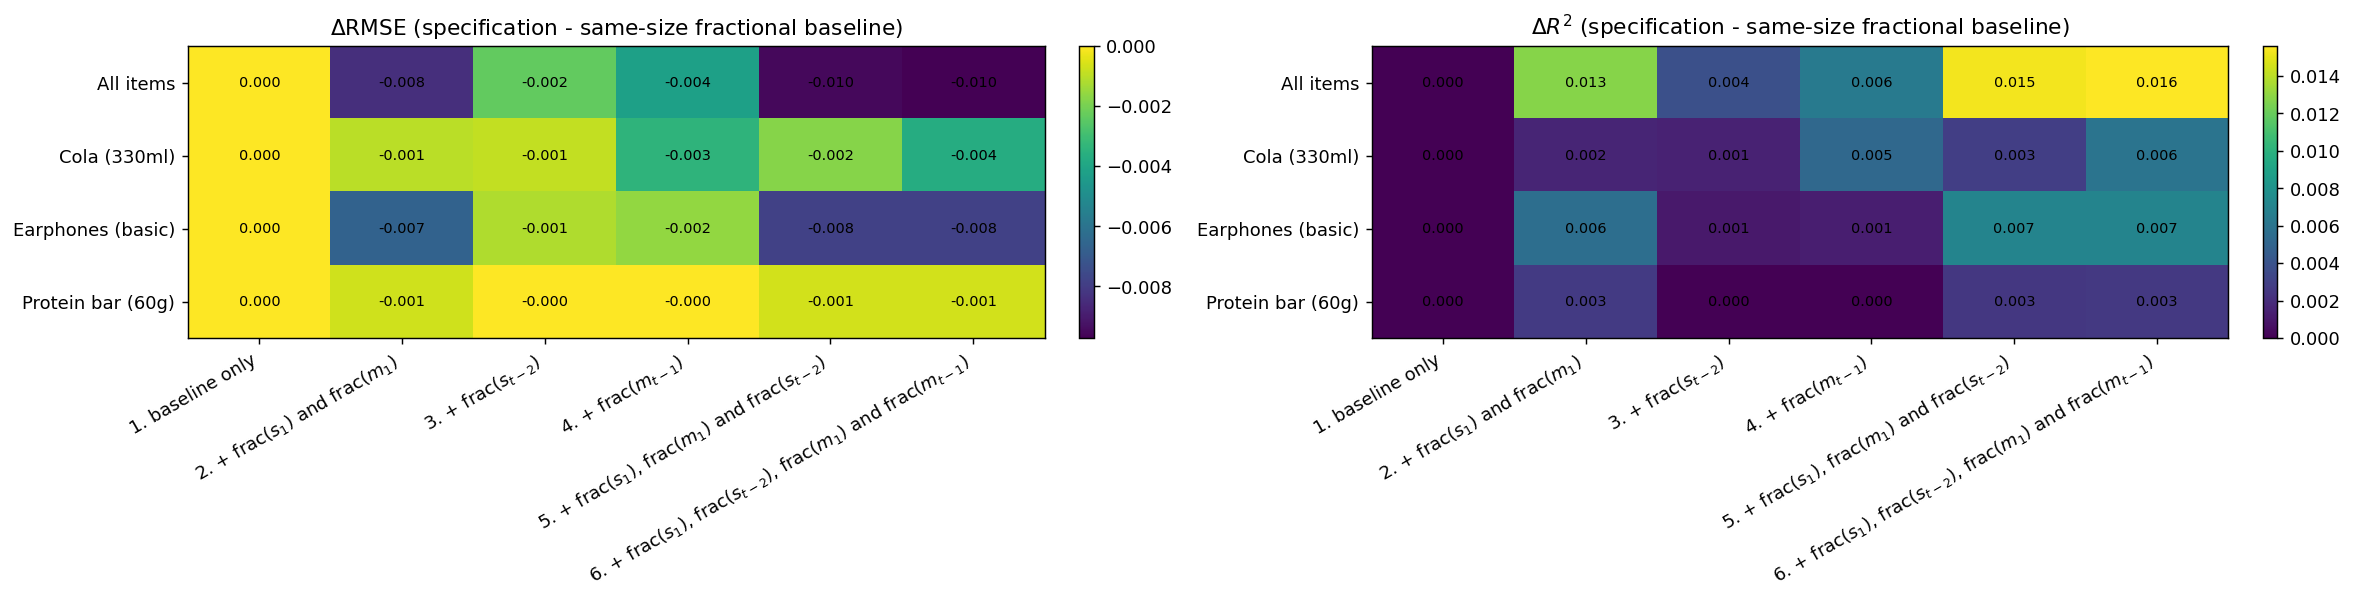

In [94]:
s72_scope_map = {"All items": all_trans}
for item_name in ITEM_ORDER:
    s72_scope_map[item_name] = [t for t in all_trans if str(t.get("product", "")) == item_name]

s72_results = {}
s72_baseline_rows = []
s72_model_rows = []

for scope_name, scope_trans in s72_scope_map.items():
    res = _fit_s72_scope(scope_name, scope_trans)
    if res is None:
        print(f"Skipping {scope_name}: insufficient usable rows after filtering.")
        continue

    s72_results[scope_name] = res
    s72_baseline_rows.append(res["baseline"])
    s72_model_rows.extend(res["models"])

S72_SCOPE_ORDER = [name for name in ["All items"] + ITEM_ORDER if name in s72_results]
S72_MODEL_ORDER = [label for label, _ in S72_MODEL_SPECS]

print("Filtered subset used in S7.2: market <= m_t and m_t >= v")
print("Estimated model family: frac(s_t) on fractional covariates")
for scope_name in S72_SCOPE_ORDER:
    print(f"  {scope_name:<28} filtered N = {s72_results[scope_name]['filtered_N']}")

_display_table(
    "Combined fractional baseline summary across scopes",
    s72_baseline_rows,
    preferred_order=[
        "scope", "filtered_N", "N",
        "beta_0", "beta_frac_m_t", "beta_frac_s_prev",
        "RMSE", "R2"
    ]
)

_display_table(
    "Combined fractional specification summary across scopes",
    s72_model_rows,
    preferred_order=[
        "scope", "filtered_N", "model_variant", "added_terms", "N",
        "RMSE_base", "RMSE_aug", "delta_RMSE",
        "R2_base", "R2_aug", "delta_R2"
    ]
)

_plot_s72_summary_heatmaps(
    s72_model_rows,
    scope_order=S72_SCOPE_ORDER,
    model_order=S72_MODEL_ORDER,
)